# 🗺️ 07 — Giá cơ bản theo TUYẾN + KHU VỰC, đã chuẩn hóa

**Vấn đề của các notebook trước (05, 05b, 06):** tính tương quan/biểu đồ trên **toàn bộ dữ liệu gộp
chung 3 tuyến × 2 loại xe**. Nếu các tuyến có mức giá nền khác nhau, biến động **giữa các tuyến**
có thể che khuất hoặc bóp méo biến động **theo thời gian trong cùng 1 tuyến**.

**Cách làm ở đây:**
1. Chia dữ liệu theo **tuyến** (điểm đón → điểm đến + loại xe)
2. Tính đơn giá cơ bản/km (`base_price_per_km`) cho từng tuyến
3. **Chuẩn hóa** (z-score) trong từng tuyến — trừ mean, chia std CỦA CHÍNH TUYẾN ĐÓ
4. So sánh: giá theo thời gian có thật sự chênh lệch không, SAU KHI đã loại bỏ khác biệt giữa các tuyến

> ### ⚠️ Phạm vi của notebook này
>
> Notebook này phân tích trên **giá cơ bản** (`base_price` = giá cuối ÷ hệ số nhân) — mục tiêu là
> tìm cách cải thiện **model giá cơ bản**, nên đã **chủ động loại bỏ phần surge**.
>
> **KHÔNG được diễn giải kết quả ở đây thành "giờ/thời tiết không ảnh hưởng giá".** Giờ/thời tiết
> tác động lên giá khách trả **qua kênh hệ số nhân (surge)**, không qua giá cơ bản. Xem
> **`00_TONG_HOP_SO_SANH.ipynb`** để có bức tranh đầy đủ (tách rõ giá cơ bản / hệ số nhân / giá cuối).

In [1]:
import sys; sys.path.insert(0, ".")
from _common import *
setup()
df = load(frac=0.15)
df["base_price"] = df[PRICE] / df[SURGE].clip(lower=0.1)
df["base_price_per_km"] = df.base_price / df.quote_distance.clip(lower=0.1)
df["tuyen"] = df.pickup_location_name + " -> " + df.dropoff_location_name + " (" + df.service_name.str.replace("Synthetic ","") + ")"
print(f"So tuyen (diem don-tra x loai xe): {df.tuyen.nunique()}")
print(df.tuyen.value_counts())

Nap 1,034,550 dong (mau 15%) | gia median 114k VND | surge 81.7%
So tuyen (diem don-tra x loai xe): 18
tuyen
SC Vivo City -> Crescent Mall (Standard Car)           88489
SC Vivo City -> Crescent Mall (Premium Car)            88123
EcoGreen Sài Gòn -> Crescent Mall (Standard Car)       86796
EcoGreen Sài Gòn -> Crescent Mall (Premium Car)        85969
Crescent Mall -> EcoGreen Sài Gòn (Standard Car)       83859
Crescent Mall -> EcoGreen Sài Gòn (Premium Car)        83490
Crescent Mall -> SC Vivo City (Standard Car)           77496
Crescent Mall -> SC Vivo City (Premium Car)            76905
SC Vivo City -> EcoGreen Sài Gòn (Premium Car)         72669
SC Vivo City -> EcoGreen Sài Gòn (Standard Car)        71462
EcoGreen Sài Gòn -> SC Vivo City (Premium Car)         65948
EcoGreen Sài Gòn -> SC Vivo City (Standard Car)        65861
SC Vivo City -> SC Vivo City (Standard Car)            15709
SC Vivo City -> SC Vivo City (Premium Car)             15686
EcoGreen Sài Gòn -> EcoGreen Sài Gòn 

**1. Thống kê giá cơ bản/km theo từng tuyến**

Mỗi tuyến có mức giá nền khác nhau không?

In [2]:
tuyen_stats = df.groupby("tuyen").base_price_per_km.agg(["count","mean","std","min","max"]).round(0)
tuyen_stats["CV"] = (tuyen_stats["std"]/tuyen_stats["mean"]).round(3)
print("Thong ke gia co ban/km theo tung tuyen:")
display(tuyen_stats.sort_values("mean", ascending=False))
print("\n-> Neu 'mean' khac nhau nhieu giua cac tuyen: gop chung se bi nhieu do khac biet TUYEN, khong phai THOI GIAN.")

Thong ke gia co ban/km theo tung tuyen:


,count,mean,std,min,max,CV
tuyen,,,,,,
Crescent Mall -> Crescent Mall (Premium Car),13623,28297.0,8442.0,7687.0,63393.0,0.298
SC Vivo City -> SC Vivo City (Premium Car),15686,27119.0,7490.0,6981.0,57637.0,0.276
EcoGreen Sài Gòn -> EcoGreen Sài Gòn (Premium Car),14221,26115.0,6806.0,8721.0,55071.0,0.261
Crescent Mall -> Crescent Mall (Standard Car),13829,23837.0,6375.0,7638.0,58645.0,0.267
SC Vivo City -> SC Vivo City (Standard Car),15709,23548.0,6141.0,8061.0,73724.0,0.261
EcoGreen Sài Gòn -> EcoGreen Sài Gòn (Standard Car),14415,23421.0,5876.0,8175.0,62441.0,0.251
EcoGreen Sài Gòn -> Crescent Mall (Standard Car),86796,16767.0,3542.0,6147.0,39030.0,0.211
Crescent Mall -> EcoGreen Sài Gòn (Standard Car),83859,16421.0,3482.0,6150.0,38072.0,0.212
EcoGreen Sài Gòn -> Crescent Mall (Premium Car),85969,16417.0,3434.0,7148.0,40927.0,0.209



-> Neu 'mean' khac nhau nhieu giua cac tuyen: gop chung se bi nhieu do khac biet TUYEN, khong phai THOI GIAN.


**2. Chuẩn hóa (z-score) trong từng tuyến**

`gia_chuan_hoa = (base_price_per_km - mean_cua_tuyen) / std_cua_tuyen`

Sau bước này, mỗi tuyến có **cùng mean=0, std=1** — khác biệt còn lại chỉ đến từ biến động
**bên trong** tuyến đó (theo giờ/thứ/tháng), không còn lẫn khác biệt **giữa** các tuyến.

In [3]:
grp = df.groupby("tuyen").base_price_per_km
df["gia_chuan_hoa"] = (df.base_price_per_km - grp.transform("mean")) / grp.transform("std")
print("Kiem tra sau chuan hoa (moi tuyen phai ~ mean=0, std=1):")
display(df.groupby("tuyen").gia_chuan_hoa.agg(["mean","std"]).round(3))

Kiem tra sau chuan hoa (moi tuyen phai ~ mean=0, std=1):


,mean,std
tuyen,,
Crescent Mall -> Crescent Mall (Premium Car),-0.0,1.0
Crescent Mall -> Crescent Mall (Standard Car),-0.0,1.0
Crescent Mall -> EcoGreen Sài Gòn (Premium Car),0.0,1.0
Crescent Mall -> EcoGreen Sài Gòn (Standard Car),-0.0,1.0
Crescent Mall -> SC Vivo City (Premium Car),-0.0,1.0
Crescent Mall -> SC Vivo City (Standard Car),0.0,1.0
EcoGreen Sài Gòn -> Crescent Mall (Premium Car),-0.0,1.0
EcoGreen Sài Gòn -> Crescent Mall (Standard Car),-0.0,1.0
EcoGreen Sài Gòn -> EcoGreen Sài Gòn (Premium Car),-0.0,1.0


**3. So sánh: biến động theo GIỜ — TRƯỚC vs SAU khi chuẩn hóa theo tuyến**

Đây là câu trả lời chính: nếu 2 đường gần giống nhau → gộp tuyến không gây sai lệch nhiều.
Nếu khác nhau rõ → phải luôn chuẩn hóa theo tuyến trước khi phân tích thời gian.

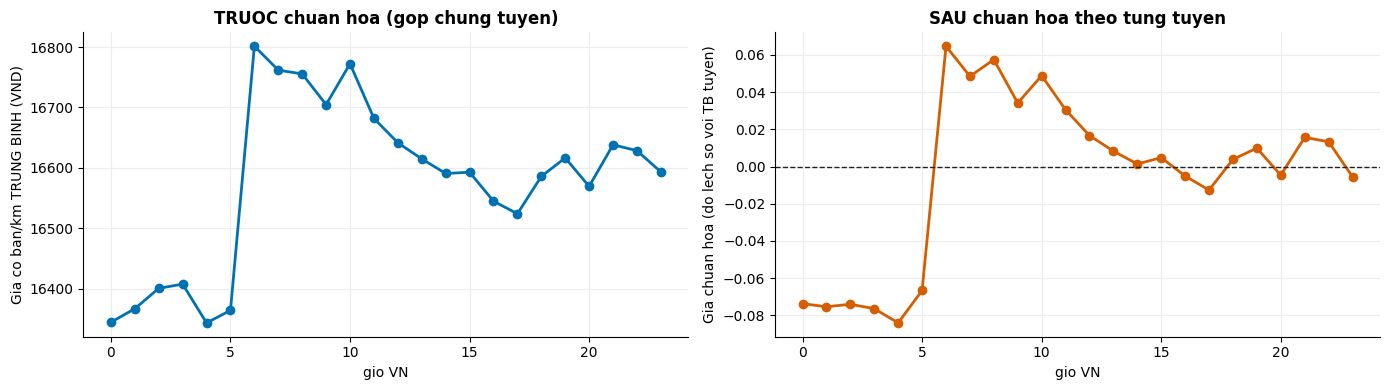

eta(gio, gia/km) TRUOC chuan hoa = 0.0284
eta(gio, gia/km) SAU  chuan hoa  = 0.0423
-> Neu eta SAU van con dang ke: gio trong ngay THAT SU anh huong gia co ban, khong phai do khac tuyen.
-> Neu eta SAU giam manh ve 0: chenh lech truoc do chi la ao giac do gop chung tuyen khac nhau.


In [4]:
g_raw = df.groupby("gio_vn").base_price_per_km.mean()
g_norm = df.groupby("gio_vn").gia_chuan_hoa.mean()

fig, ax = plt.subplots(1, 2, figsize=(14,4))
ax[0].plot(g_raw.index, g_raw.values, marker="o", color=BLUE, lw=2)
ax[0].set_xlabel("gio VN"); ax[0].set_ylabel("Gia co ban/km TRUNG BINH (VND)")
ax[0].set_title("TRUOC chuan hoa (gop chung tuyen)", fontweight="bold")

ax[1].plot(g_norm.index, g_norm.values, marker="o", color=RED, lw=2)
ax[1].axhline(0, color="#222", ls="--", lw=1)
ax[1].set_xlabel("gio VN"); ax[1].set_ylabel("Gia chuan hoa (do lech so voi TB tuyen)")
ax[1].set_title("SAU chuan hoa theo tung tuyen", fontweight="bold")
plt.tight_layout(); plt.show()

eta_raw = eta(df.gio_vn, df.base_price_per_km)
eta_norm = eta(df.gio_vn, df.gia_chuan_hoa)
print(f"eta(gio, gia/km) TRUOC chuan hoa = {eta_raw:.4f}")
print(f"eta(gio, gia/km) SAU  chuan hoa  = {eta_norm:.4f}")
print("-> Neu eta SAU van con dang ke: gio trong ngay THAT SU anh huong gia co ban, khong phai do khac tuyen.")
print("-> Neu eta SAU giam manh ve 0: chenh lech truoc do chi la ao giac do gop chung tuyen khac nhau.")

**4. Tương tự — biến động theo THỨ trong tuần và THÁNG (mốc thời gian)**

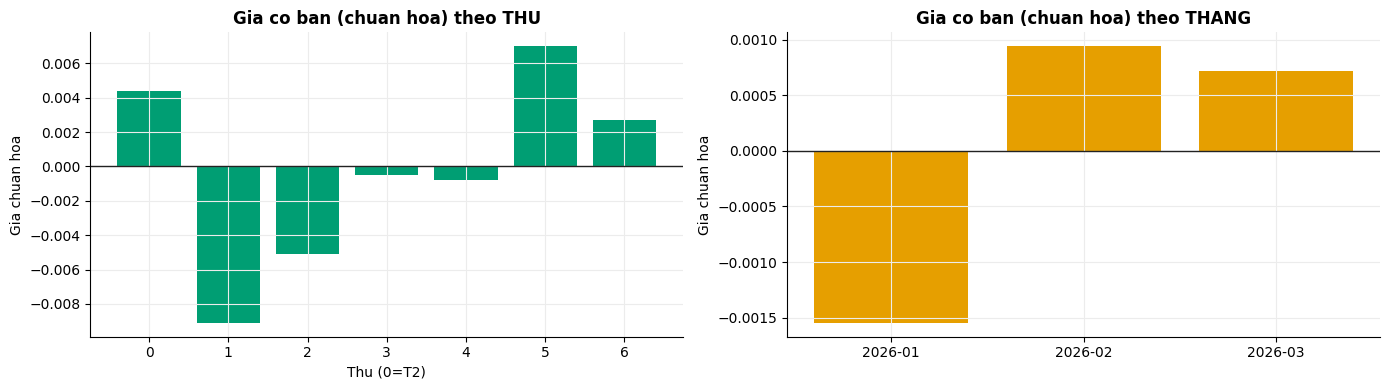

eta(thu, gia chuan hoa)   = 0.0051
eta(thang, gia chuan hoa) = 0.0011


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
g_thu = df.groupby("thu_vn").gia_chuan_hoa.mean()
ax[0].bar(g_thu.index, g_thu.values, color=GREEN)
ax[0].axhline(0, color="#222", lw=1); ax[0].set_xlabel("Thu (0=T2)"); ax[0].set_ylabel("Gia chuan hoa")
ax[0].set_title("Gia co ban (chuan hoa) theo THU", fontweight="bold")

g_thang = df.groupby("evaluation_month").gia_chuan_hoa.mean()
ax[1].bar(range(len(g_thang)), g_thang.values, color=ORANGE)
ax[1].set_xticks(range(len(g_thang))); ax[1].set_xticklabels(g_thang.index)
ax[1].axhline(0, color="#222", lw=1); ax[1].set_ylabel("Gia chuan hoa")
ax[1].set_title("Gia co ban (chuan hoa) theo THANG", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"eta(thu, gia chuan hoa)   = {eta(df.thu_vn, df.gia_chuan_hoa):.4f}")
print(f"eta(thang, gia chuan hoa) = {eta(df.evaluation_month, df.gia_chuan_hoa):.4f}")

**5. Theo KHU VỰC (điểm đón) — sau chuẩn hóa theo tuyến, khu vực nào biến động mạnh nhất?**

In [6]:
g_khu = df.groupby("pickup_location_name").gia_chuan_hoa.agg(["mean","std"]).round(3)
print("Do bien dong gia (sau chuan hoa) theo khu vuc diem don:")
display(g_khu)
print(f"\neta(khu vuc don, gia chuan hoa) = {eta(df.pickup_location_name, df.gia_chuan_hoa):.4f}")
print("-> Neu std khac nhau nhieu giua cac khu: co khu bien dong gia manh hon (nhieu hon) khu khac.")

Do bien dong gia (sau chuan hoa) theo khu vuc diem don:


,mean,std
pickup_location_name,,
Crescent Mall,-0.0,1.0
EcoGreen Sài Gòn,-0.0,1.0
SC Vivo City,0.0,1.0



eta(khu vuc don, gia chuan hoa) = 0.0000
-> Neu std khac nhau nhieu giua cac khu: co khu bien dong gia manh hon (nhieu hon) khu khac.


**Kết luận**

- Bước 1 xác nhận các tuyến có mức giá nền (`mean`) khác nhau hay không — nếu khác nhiều, mọi phân
  tích gộp chung tuyến trước đây (05, 05b, 06) cần đọc lại thận trọng.
- Bước 3-4: so **eta trước/sau chuẩn hóa** theo giờ/thứ/tháng — đây là bằng chứng định lượng cho biết
  biến động thời gian quan sát được trước đó là **thật** (giữ nguyên sau chuẩn hóa) hay **ảo** (biến
  mất sau chuẩn hóa, tức chỉ do gộp lẫn các tuyến khác giá nền nhau).
- Bước 5: phát hiện khu vực nào có giá dao động mạnh hơn — hữu ích nếu muốn thêm feature "biến động
  theo khu vực" cho model giá cơ bản.